# FIX vs GO Neural Decoder - Temporal Analysis

This notebook extends the decoder analysis with two temporal approaches:

1. **Sliding Window Cross-Temporal Generalization**: Train classifiers at different time points, test on all time points → reveals if representations are stable or dynamic

2. **Time-Binned Activity (PSTH Features)**: Use binned spike counts instead of epoch means → preserves temporal dynamics within epochs

**Reference**: Xie et al. (2022) "Geometry of sequence working memory in macaque prefrontal cortex"

## 1. Imports and Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pickle
import sys
from tqdm.auto import tqdm

# Add parent directory to path
sys.path.insert(0, str(Path.cwd().parent))

import importlib
import session_class
import cell_analysis
importlib.reload(session_class)
importlib.reload(cell_analysis)

from session_class import Session
from cell_analysis import Cell

# Scikit-learn
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score

print("Imports loaded successfully!")

Imports loaded successfully!


## 2. Configuration

In [3]:
# Data paths
base_path = Path.cwd().parents[1] / 'data' / 'unified_cell_trial_data'
pickle_file = base_path / 'msn_fiona_cell_trial_data.pkl'

# Session selection
SESSION_ID = 'fi211025a'

# Parameters from Phase 1
SSD_NUM = 2
RT_MULTIPLIER = 1.3
TEST_SIZE = 0.2
RANDOM_STATE = 42

# Sliding window parameters (in multiples of mean_ssd)
WINDOW_START_MULT = -2.0  # Start at -2×mean_ssd
WINDOW_END_MULT = 3.0      # End at 3×mean_ssd
WINDOW_STEP_MULT = 0.2     # Step by 0.2×mean_ssd
WINDOW_WIDTH_MULT = 1.0    # Each window is 1×mean_ssd wide

# Time-binned parameters
BIN_SIZE_MS = 25  # 25ms bins for PSTH features

# Direction mapping
dir_map = {0: 'Right', 180: 'Left'}
directions = [0, 180]

print(f"Configuration:")
print(f"  Session: {SESSION_ID}")
print(f"  Sliding window: {WINDOW_START_MULT}× to {WINDOW_END_MULT}× mean_ssd")
print(f"  Step size: {WINDOW_STEP_MULT}× mean_ssd")
print(f"  Window width: {WINDOW_WIDTH_MULT}× mean_ssd")
print(f"  Time-binned bin size: {BIN_SIZE_MS}ms")

Configuration:
  Session: fi211025a
  Sliding window: -2.0× to 3.0× mean_ssd
  Step size: 0.2× mean_ssd
  Window width: 1.0× mean_ssd
  Time-binned bin size: 25ms


## 3. Load and Prepare Data

In [4]:
# Load MSN cell database
print("Loading cell database...")
cell_df = pd.read_pickle(pickle_file)

# Select session
session_data = cell_df[cell_df['trial_session'] == SESSION_ID]
session = Session(session_data, verbose=True)
session.drop_cells_with_missing_trial_type_or_dir_data()

print(f"\n✓ Session loaded: {session.n_cells} cells")

Loading cell database...
Session fi211025a initialized:
  - Number of cells: 150
  - Total trials: 1950
  - Trial types: ['CONT', 'GO', 'STOP']
  - Directions: [np.int64(0), np.int64(180)]

✓ Session loaded: 150 cells


In [5]:
def compute_mean_ssd(session_data, direction, ssd_number):
    """Compute mean SSD length for a given direction and SSD level."""
    stop_trials = session_data[
        (session_data['type'] == 'STOP') &
        (session_data['trial_failed'] == False) &
        (session_data['dir'] == direction) &
        (session_data['ssd_number'] == ssd_number)
    ]
    return stop_trials['ssd_len'].mean()


def filter_go_trials(session_data, direction, mean_ssd, rt_multiplier=1.3):
    """Filter GO trials: successful with RT > rt_multiplier × mean_ssd."""
    mask = (
        (session_data['type'] == 'GO') &
        (session_data['dir'] == direction) &
        (session_data['trial_failed'] == False)
    )
    go_trials = session_data[mask].copy()
    rt_threshold = rt_multiplier * mean_ssd
    return go_trials[go_trials['reaction_time'] > rt_threshold]


# Compute mean_ssd and filter trials per direction
mean_ssd_dict = {}
filtered_data_by_dir = {}

print("Preparing data per direction:")
print("=" * 60)

for direction in directions:
    mean_ssd = compute_mean_ssd(session.data, direction, SSD_NUM)
    mean_ssd_dict[direction] = mean_ssd
    
    filtered_go = filter_go_trials(session.data, direction, mean_ssd, RT_MULTIPLIER)
    filtered_data_by_dir[direction] = filtered_go
    
    n_trials = len(filtered_go['trial_number'].unique())
    print(f"\n{dir_map[direction]} ({direction}°):")
    print(f"  mean_ssd2: {mean_ssd:.2f} ms")
    print(f"  Filtered GO trials: {n_trials}")

Preparing data per direction:

Right (0°):
  mean_ssd2: 108.00 ms
  Filtered GO trials: 435

Left (180°):
  mean_ssd2: 108.00 ms
  Filtered GO trials: 449


---

# Part 1: Sliding Window Cross-Temporal Generalization

Train a classifier at each time window, then test it on ALL time windows.
The resulting matrix (train_time × test_time) reveals:
- **Diagonal**: How well each time point can be decoded
- **Off-diagonal**: Whether representations generalize across time

In [6]:
def extract_window_features(trial_data, window_start_ms, window_end_ms, cell_ids):
    """
    Extract mean firing rate features for a single time window.
    
    Parameters:
    -----------
    trial_data : DataFrame
        Filtered trial data (all cells for multiple trials)
    window_start_ms : float
        Window start time (ms relative to go_cue)
    window_end_ms : float
        Window end time (ms relative to go_cue)
    cell_ids : list
        Ordered list of cell IDs
    
    Returns:
    --------
    X : ndarray (n_trials, n_neurons)
        Feature matrix (mean FR per neuron)
    trial_numbers : list
        Trial numbers corresponding to rows
    """
    trial_numbers = sorted(trial_data['trial_number'].unique())
    n_trials = len(trial_numbers)
    n_neurons = len(cell_ids)
    
    X = np.zeros((n_trials, n_neurons))
    
    duration_sec = (window_end_ms - window_start_ms) / 1000.0
    
    for trial_idx, trial_num in enumerate(trial_numbers):
        trial_cells = trial_data[trial_data['trial_number'] == trial_num]
        
        for _, cell_row in trial_cells.iterrows():
            cell_id = cell_row['cell_ID']
            if cell_id not in cell_ids:
                continue
            
            neuron_idx = cell_ids.index(cell_id)
            
            # Get spike times relative to go_cue
            spike_times = np.array(cell_row['neural_data'], dtype=np.float64)
            go_cue = cell_row['go_cue']
            relative_spikes = spike_times - go_cue
            
            # Count spikes in window
            spikes_in_window = relative_spikes[
                (relative_spikes >= window_start_ms) & (relative_spikes < window_end_ms)
            ]
            
            # Convert to firing rate
            X[trial_idx, neuron_idx] = len(spikes_in_window) / duration_sec
    
    return X, trial_numbers


print("✓ Window feature extraction function defined")

✓ Window feature extraction function defined


In [7]:
def build_sliding_window_data(trial_data, mean_ssd, cell_ids,
                               start_mult=-2.0, end_mult=3.0, 
                               step_mult=0.2, width_mult=1.0):
    """
    Build feature matrices for all sliding windows.
    
    Parameters:
    -----------
    trial_data : DataFrame
        Filtered trial data
    mean_ssd : float
        Mean SSD length in ms
    cell_ids : list
        Ordered list of cell IDs
    start_mult, end_mult : float
        Time range in multiples of mean_ssd
    step_mult : float
        Step size in multiples of mean_ssd
    width_mult : float
        Window width in multiples of mean_ssd
    
    Returns:
    --------
    window_data : dict
        {window_idx: {'X': features, 'center_ms': center_time, ...}}
    window_centers : list
        Center times (in ms) for each window
    """
    # Generate window centers
    window_centers_mult = np.arange(start_mult, end_mult + step_mult/2, step_mult)
    window_centers_ms = window_centers_mult * mean_ssd
    window_width_ms = width_mult * mean_ssd
    
    window_data = {}
    
    print(f"Building {len(window_centers_ms)} sliding windows...")
    print(f"Window width: {window_width_ms:.1f} ms")
    
    for idx, center_ms in enumerate(tqdm(window_centers_ms, desc="Extracting windows")):
        window_start = center_ms - window_width_ms / 2
        window_end = center_ms + window_width_ms / 2
        
        X, trial_numbers = extract_window_features(
            trial_data, window_start, window_end, cell_ids
        )
        
        # Assign label: FIX (0) if center < 0, GO (1) if center >= 0
        label = 0 if center_ms < 0 else 1
        
        window_data[idx] = {
            'X': X,
            'trial_numbers': trial_numbers,
            'center_ms': center_ms,
            'center_mult': window_centers_mult[idx],
            'window_start': window_start,
            'window_end': window_end,
            'label': label,
            'label_name': 'FIX' if label == 0 else 'GO'
        }
    
    return window_data, list(window_centers_ms)


print("✓ Sliding window builder function defined")

✓ Sliding window builder function defined


In [8]:
# Build sliding window data for each direction
sliding_data_by_dir = {}

for direction in directions:
    print(f"\n{'='*60}")
    print(f"{dir_map[direction]} Direction ({direction}°)")
    print("="*60)
    
    trial_data = filtered_data_by_dir[direction]
    mean_ssd = mean_ssd_dict[direction]
    cell_ids = sorted(trial_data['cell_ID'].unique())
    
    window_data, window_centers = build_sliding_window_data(
        trial_data, mean_ssd, cell_ids,
        start_mult=WINDOW_START_MULT,
        end_mult=WINDOW_END_MULT,
        step_mult=WINDOW_STEP_MULT,
        width_mult=WINDOW_WIDTH_MULT
    )
    
    sliding_data_by_dir[direction] = {
        'window_data': window_data,
        'window_centers': window_centers,
        'cell_ids': cell_ids,
        'mean_ssd': mean_ssd
    }
    
    print(f"\n✓ {len(window_data)} windows extracted")
    print(f"  Window centers: {window_centers[0]:.1f} to {window_centers[-1]:.1f} ms")


Right Direction (0°)
Building 26 sliding windows...
Window width: 108.0 ms


Extracting windows:   0%|          | 0/26 [00:00<?, ?it/s]


✓ 26 windows extracted
  Window centers: -216.0 to 324.0 ms

Left Direction (180°)
Building 26 sliding windows...
Window width: 108.0 ms


Extracting windows:   0%|          | 0/26 [00:00<?, ?it/s]


✓ 26 windows extracted
  Window centers: -216.0 to 324.0 ms


In [9]:
def normalize_features(X_train, X_test=None):
    """Z-score normalize features per neuron using training statistics."""
    neuron_mean = X_train.mean(axis=0)
    neuron_std = X_train.std(axis=0)
    neuron_std[neuron_std == 0] = 1.0

    X_train_norm = (X_train - neuron_mean) / neuron_std

    if X_test is not None:
        X_test_norm = (X_test - neuron_mean) / neuron_std
        return X_train_norm, X_test_norm, neuron_mean, neuron_std

    return X_train_norm, neuron_mean, neuron_std


def train_and_test_cross_temporal(window_data, test_size=0.2, random_state=42):
    """
    Cross-temporal generalization analysis.

    For each pair (train_time, test_time):
    - Train a classifier using FIX data from train_time and GO data from train_time
      (where FIX/GO times are symmetric around go_cue)
    - Test on data from test_time

    Parameters:
    -----------
    window_data : dict
        {window_idx: {'X': features, 'center_ms': time, 'label': label, ...}}
    test_size : float
        Fraction for test set
    random_state : int
        Random seed

    Returns:
    --------
    accuracy_matrix : ndarray (n_windows, n_windows)
        Entry (i, j) = accuracy when training on window i, testing on window j
    prob_go_matrix : ndarray (n_windows, n_windows)
        Entry (i, j) = mean P(GO) when training on window i, testing on window j
    """
    n_windows = len(window_data)
    accuracy_matrix = np.zeros((n_windows, n_windows))
    prob_go_matrix = np.zeros((n_windows, n_windows))
    models = {}

    # Create consistent train/test split based on trial numbers
    trial_numbers = window_data[0]['trial_numbers']
    n_trials = len(trial_numbers)

    indices = np.arange(n_trials)
    train_idx, test_idx = train_test_split(
        indices, test_size=test_size, random_state=random_state
    )

    print(f"Train/test split: {len(train_idx)} train, {len(test_idx)} test trials")
    print(f"Training {n_windows} classifiers...")

    # Identify FIX and GO window indices
    fix_windows = [i for i, w in window_data.items() if w['label'] == 0]
    go_windows = [i for i, w in window_data.items() if w['label'] == 1]

    # For each training configuration, pair a FIX time with a GO time
    # Strategy: Use symmetric pairing around go_cue when possible
    for train_window_idx in tqdm(range(n_windows), desc="Training classifiers"):
        train_win = window_data[train_window_idx]
        train_center = train_win['center_ms']

        # Find the "paired" window from the opposite class
        # For FIX windows, pair with GO window at |t| ms after go_cue
        # For GO windows, pair with FIX window at -t ms before go_cue
        if train_win['label'] == 0:  # FIX
            # This window is before go_cue, pair with symmetric GO window
            target_center = -train_center  # Mirror around 0
            paired_idx = min(go_windows, key=lambda i: abs(window_data[i]['center_ms'] - target_center))
        else:  # GO
            # This window is after go_cue, pair with symmetric FIX window
            target_center = -train_center  # Mirror around 0
            paired_idx = min(fix_windows, key=lambda i: abs(window_data[i]['center_ms'] - target_center))

        paired_win = window_data[paired_idx]

        # Build training data: FIX samples + GO samples
        if train_win['label'] == 0:
            X_fix = train_win['X'][train_idx]
            X_go = paired_win['X'][train_idx]
        else:
            X_go = train_win['X'][train_idx]
            X_fix = paired_win['X'][train_idx]

        X_train_combined = np.vstack([X_fix, X_go])
        y_train_combined = np.concatenate([
            np.zeros(len(X_fix), dtype=int),
            np.ones(len(X_go), dtype=int)
        ])

        # Normalize
        X_train_norm, neuron_mean, neuron_std = normalize_features(X_train_combined)

        # Train classifier
        clf = LogisticRegression(
            penalty='l2', C=1.0, solver='lbfgs', max_iter=1000,
            class_weight='balanced', random_state=random_state
        )
        clf.fit(X_train_norm, y_train_combined)

        models[train_window_idx] = {
            'model': clf,
            'neuron_mean': neuron_mean,
            'neuron_std': neuron_std,
            'paired_window_idx': paired_idx
        }

        # Test on all windows
        for test_window_idx in range(n_windows):
            test_win = window_data[test_window_idx]
            X_test = test_win['X'][test_idx]
            y_test = np.full(len(X_test), test_win['label'])

            # Normalize using training statistics
            X_test_norm = (X_test - neuron_mean) / neuron_std

            # Predict
            y_pred = clf.predict(X_test_norm)
            y_prob = clf.predict_proba(X_test_norm)[:, 1]

            accuracy_matrix[train_window_idx, test_window_idx] = accuracy_score(y_test, y_pred)
            prob_go_matrix[train_window_idx, test_window_idx] = y_prob.mean()

    return accuracy_matrix, prob_go_matrix, models, train_idx, test_idx


print("✓ Cross-temporal training function defined")

✓ Cross-temporal training function defined


In [10]:
# Run cross-temporal generalization analysis for each direction
cross_temporal_results = {}

for direction in directions:
    print(f"\n{'='*60}")
    print(f"{dir_map[direction]} Direction ({direction}°)")
    print("="*60)

    data = sliding_data_by_dir[direction]

    accuracy_matrix, prob_go_matrix, models, train_idx, test_idx = train_and_test_cross_temporal(
        data['window_data'],
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE
    )

    cross_temporal_results[direction] = {
        'accuracy_matrix': accuracy_matrix,
        'prob_go_matrix': prob_go_matrix,
        'models': models,
        'train_idx': train_idx,
        'test_idx': test_idx,
        'window_centers': data['window_centers'],
        'mean_ssd': data['mean_ssd']
    }

    print(f"\n✓ Cross-temporal analysis complete")
    print(f"  Diagonal mean accuracy: {np.diag(accuracy_matrix).mean():.3f}")


Right Direction (0°)
Train/test split: 348 train, 87 test trials
Training 26 classifiers...


Training classifiers:   0%|          | 0/26 [00:00<?, ?it/s]

/home/barak/Projects/population-analysis/.conda/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/barak/Projects/population-analysis/.conda/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/barak/Projects/population-analysis/.conda/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penal


✓ Cross-temporal analysis complete
  Diagonal mean accuracy: 0.744

Left Direction (180°)
Train/test split: 359 train, 90 test trials
Training 26 classifiers...


/home/barak/Projects/population-analysis/.conda/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/barak/Projects/population-analysis/.conda/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/barak/Projects/population-analysis/.conda/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penal

Training classifiers:   0%|          | 0/26 [00:00<?, ?it/s]

/home/barak/Projects/population-analysis/.conda/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/barak/Projects/population-analysis/.conda/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/barak/Projects/population-analysis/.conda/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penal


✓ Cross-temporal analysis complete
  Diagonal mean accuracy: 0.762


/home/barak/Projects/population-analysis/.conda/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/barak/Projects/population-analysis/.conda/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/barak/Projects/population-analysis/.conda/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penal

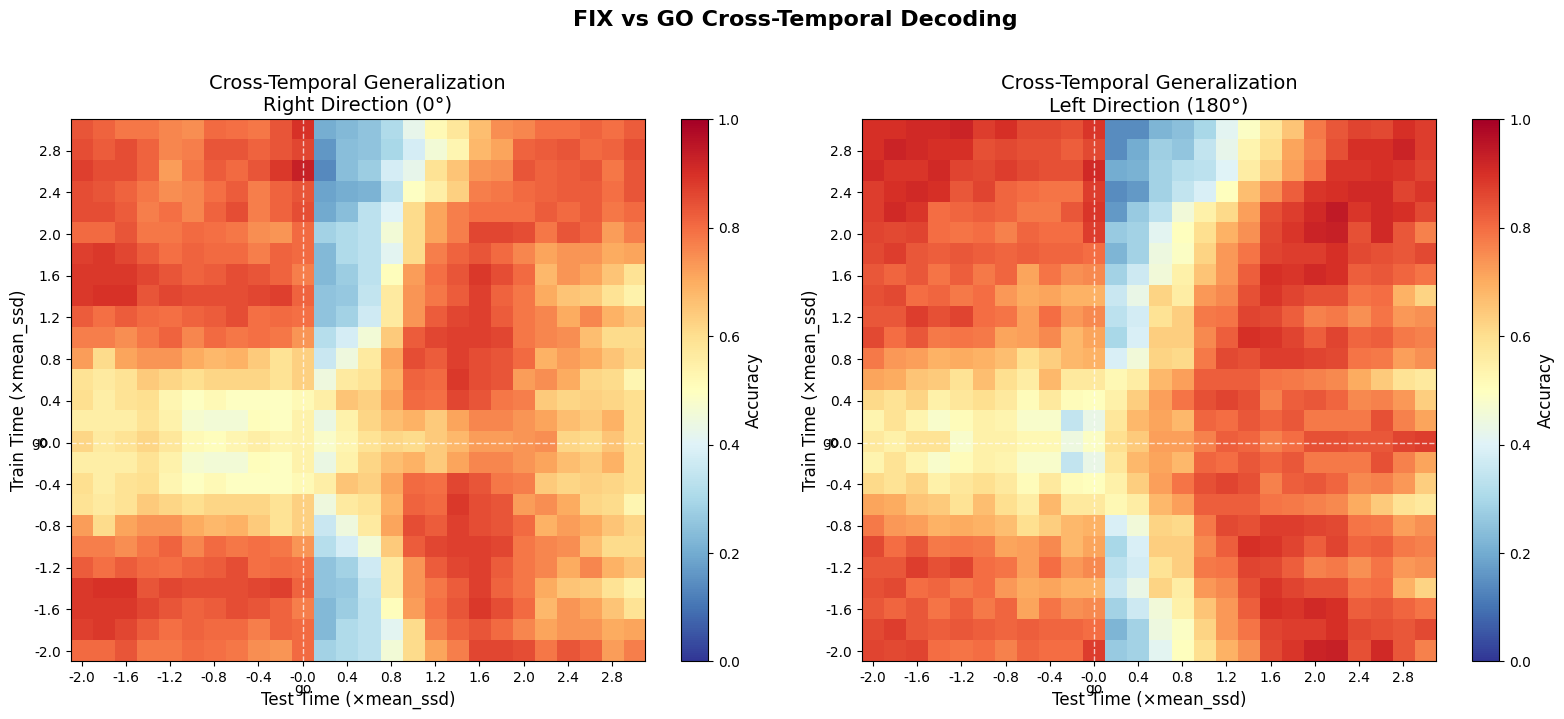

In [11]:
def plot_cross_temporal_matrix(accuracy_matrix, window_centers, mean_ssd, 
                                direction_name, ax=None):
    """
    Plot cross-temporal generalization matrix.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))
    
    # Convert window centers to multiples of mean_ssd for labels
    window_mults = np.array(window_centers) / mean_ssd
    
    im = ax.imshow(accuracy_matrix, cmap='RdYlBu_r', aspect='auto',
                   vmin=0.0, vmax=1.0, origin='lower')
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Accuracy', fontsize=12)
    
    # Set tick positions and labels
    n_windows = len(window_centers)
    tick_step = max(1, n_windows // 10)
    tick_positions = np.arange(0, n_windows, tick_step)
    tick_labels = [f"{window_mults[i]:.1f}" for i in tick_positions]
    
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels)
    ax.set_yticks(tick_positions)
    ax.set_yticklabels(tick_labels)
    
    ax.set_xlabel('Test Time (×mean_ssd)', fontsize=12)
    ax.set_ylabel('Train Time (×mean_ssd)', fontsize=12)
    ax.set_title(f'Cross-Temporal Generalization\n{direction_name}', fontsize=14)
    
    # Add lines at t=0 (go cue)
    zero_idx = np.argmin(np.abs(window_mults))
    ax.axhline(y=zero_idx, color='white', linestyle='--', linewidth=1, alpha=0.7)
    ax.axvline(x=zero_idx, color='white', linestyle='--', linewidth=1, alpha=0.7)
    
    # Add text annotation for go cue
    ax.text(zero_idx, -1.5, 'go', ha='center', va='top', fontsize=10, color='black')
    ax.text(-1.5, zero_idx, 'go', ha='right', va='center', fontsize=10, color='black')
    
    return ax


# Plot cross-temporal matrices
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for idx, direction in enumerate(directions):
    results = cross_temporal_results[direction]
    plot_cross_temporal_matrix(
        results['accuracy_matrix'],
        results['window_centers'],
        results['mean_ssd'],
        f"{dir_map[direction]} Direction ({direction}°)",
        ax=axes[idx]
    )

plt.suptitle('FIX vs GO Cross-Temporal Decoding', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

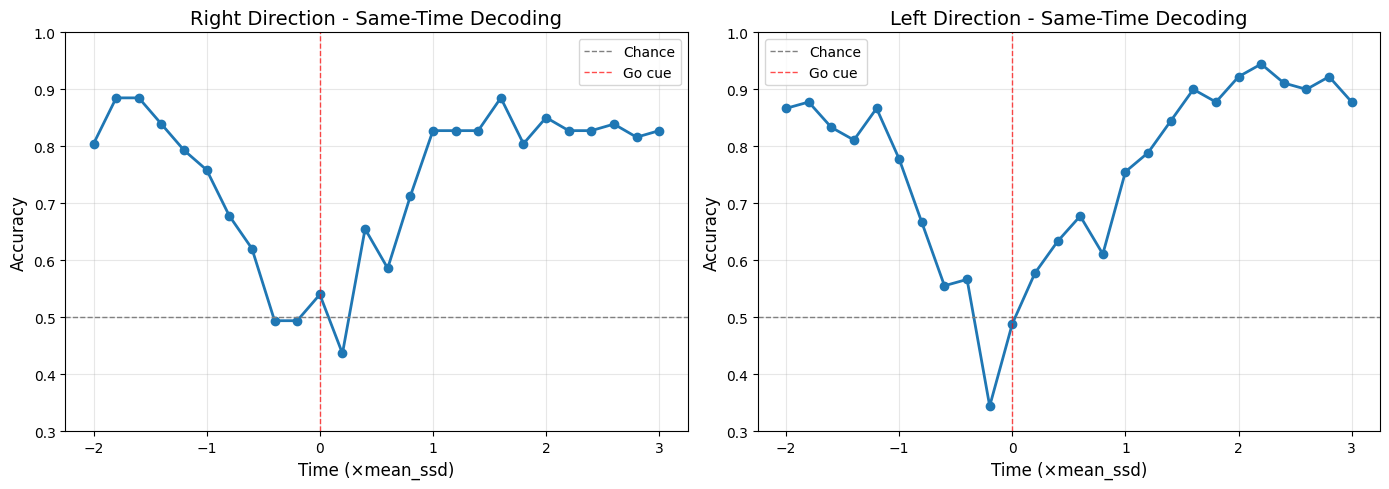


Diagonal (same-time) accuracy statistics:
  Right: mean=0.744, min=0.437, max=0.885
  Left: mean=0.762, min=0.344, max=0.944


In [12]:
# Plot diagonal (same-time accuracy) vs time
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, direction in enumerate(directions):
    ax = axes[idx]
    results = cross_temporal_results[direction]
    
    window_mults = np.array(results['window_centers']) / results['mean_ssd']
    diagonal_acc = np.diag(results['accuracy_matrix'])
    
    ax.plot(window_mults, diagonal_acc, 'o-', linewidth=2, markersize=6)
    ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=1, label='Chance')
    ax.axvline(x=0, color='red', linestyle='--', linewidth=1, alpha=0.7, label='Go cue')
    
    ax.set_xlabel('Time (×mean_ssd)', fontsize=12)
    ax.set_ylabel('Accuracy', fontsize=12)
    ax.set_title(f'{dir_map[direction]} Direction - Same-Time Decoding', fontsize=14)
    ax.set_ylim(0.3, 1.0)
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nDiagonal (same-time) accuracy statistics:")
for direction in directions:
    diag = np.diag(cross_temporal_results[direction]['accuracy_matrix'])
    print(f"  {dir_map[direction]}: mean={diag.mean():.3f}, min={diag.min():.3f}, max={diag.max():.3f}")

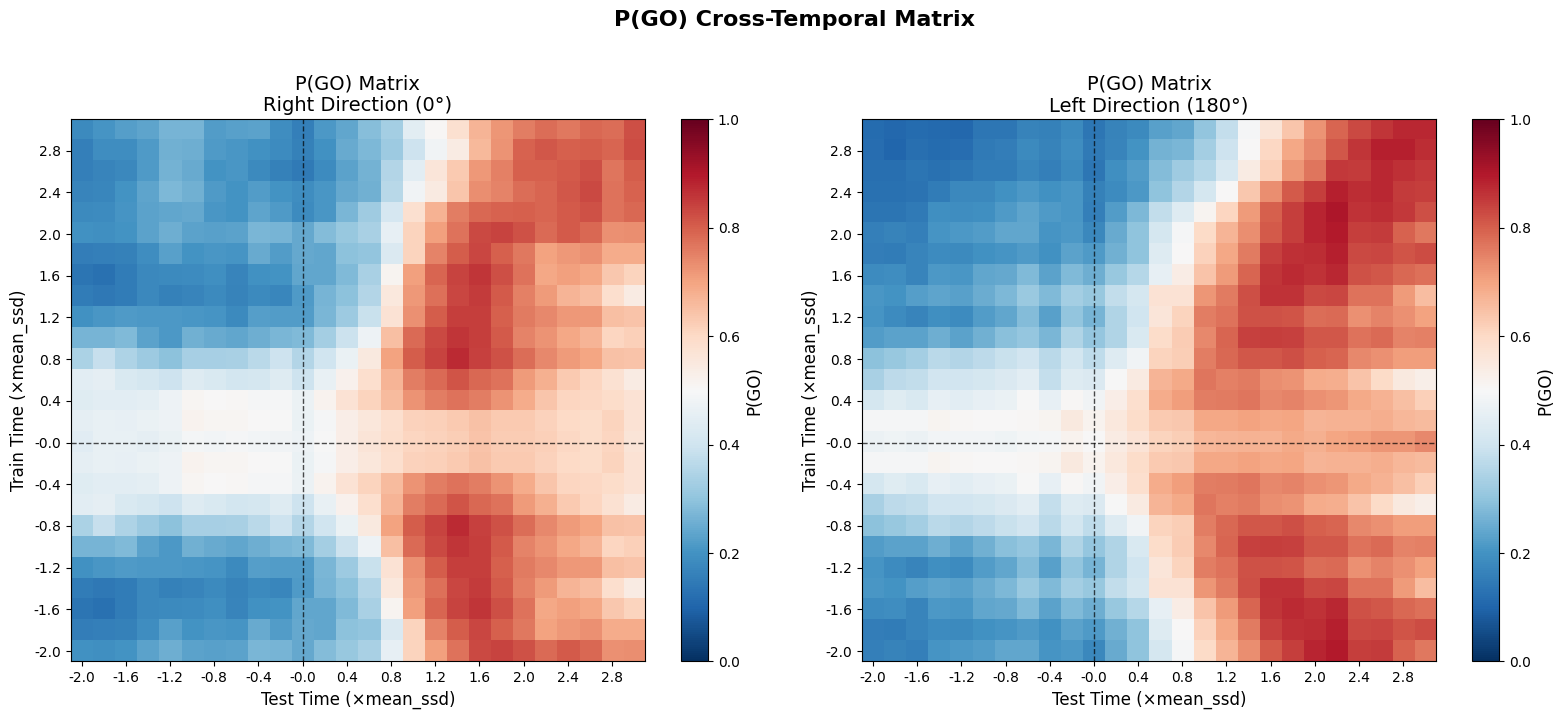

In [13]:
# Plot P(GO) matrix (mean probability of GO classification across test trials)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for idx, direction in enumerate(directions):
    results = cross_temporal_results[direction]
    ax = axes[idx]

    window_mults = np.array(results['window_centers']) / results['mean_ssd']

    im = ax.imshow(results['prob_go_matrix'], cmap='RdBu_r', aspect='auto',
                   vmin=0.0, vmax=1.0, origin='lower')

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('P(GO)', fontsize=12)

    n_windows = len(results['window_centers'])
    tick_step = max(1, n_windows // 10)
    tick_positions = np.arange(0, n_windows, tick_step)
    tick_labels = [f"{window_mults[i]:.1f}" for i in tick_positions]

    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels)
    ax.set_yticks(tick_positions)
    ax.set_yticklabels(tick_labels)

    ax.set_xlabel('Test Time (×mean_ssd)', fontsize=12)
    ax.set_ylabel('Train Time (×mean_ssd)', fontsize=12)
    ax.set_title(f'P(GO) Matrix\n{dir_map[direction]} Direction ({direction}°)', fontsize=14)

    # Add lines at t=0 (go cue)
    zero_idx = np.argmin(np.abs(window_mults))
    ax.axhline(y=zero_idx, color='black', linestyle='--', linewidth=1, alpha=0.7)
    ax.axvline(x=zero_idx, color='black', linestyle='--', linewidth=1, alpha=0.7)

plt.suptitle('P(GO) Cross-Temporal Matrix', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### P(GO) Trajectory with Single Canonical Classifier

Train one classifier using canonical FIX and GO epochs (FIX_late and GO_late), then track P(GO) across all time windows.

In [14]:
def train_canonical_classifier_and_test_trajectory(window_data, fix_mult=-0.5, go_mult=1.5,
                                                    test_size=0.2, random_state=42):
    """
    Train a single classifier on canonical FIX/GO epochs and test at all time points.

    Parameters:
    -----------
    window_data : dict
        Sliding window data
    fix_mult : float
        Center time (in mean_ssd units) for FIX training data
    go_mult : float
        Center time (in mean_ssd units) for GO training data
    """
    n_windows = len(window_data)
    trial_numbers = window_data[0]['trial_numbers']
    n_trials = len(trial_numbers)

    # Get mean_ssd from window data
    mean_ssd = abs(window_data[0]['center_ms'] / window_data[0]['center_mult'])

    # Find windows closest to canonical times
    fix_target = fix_mult * mean_ssd
    go_target = go_mult * mean_ssd

    fix_window_idx = min(range(n_windows), key=lambda i: abs(window_data[i]['center_ms'] - fix_target))
    go_window_idx = min(range(n_windows), key=lambda i: abs(window_data[i]['center_ms'] - go_target))

    print(f"Canonical training windows:")
    print(f"  FIX: window {fix_window_idx}, center = {window_data[fix_window_idx]['center_ms']:.1f} ms")
    print(f"  GO: window {go_window_idx}, center = {window_data[go_window_idx]['center_ms']:.1f} ms")

    # Create train/test split
    indices = np.arange(n_trials)
    train_idx, test_idx = train_test_split(
        indices, test_size=test_size, random_state=random_state
    )

    # Build training data
    X_fix = window_data[fix_window_idx]['X'][train_idx]
    X_go = window_data[go_window_idx]['X'][train_idx]

    X_train = np.vstack([X_fix, X_go])
    y_train = np.concatenate([np.zeros(len(X_fix)), np.ones(len(X_go))])

    # Normalize
    X_train_norm, neuron_mean, neuron_std = normalize_features(X_train)

    # Train classifier
    clf = LogisticRegression(
        penalty='l2', C=1.0, solver='lbfgs', max_iter=1000,
        class_weight='balanced', random_state=random_state
    )
    clf.fit(X_train_norm, y_train)

    # Test at all time points
    p_go_trajectory = np.zeros(n_windows)
    p_go_std = np.zeros(n_windows)
    accuracy_trajectory = np.zeros(n_windows)

    for window_idx in range(n_windows):
        X_test = window_data[window_idx]['X'][test_idx]
        y_test = np.full(len(X_test), window_data[window_idx]['label'])

        # Normalize using training statistics
        X_test_norm = (X_test - neuron_mean) / neuron_std

        # Predict
        y_pred = clf.predict(X_test_norm)
        y_prob = clf.predict_proba(X_test_norm)[:, 1]

        p_go_trajectory[window_idx] = y_prob.mean()
        p_go_std[window_idx] = y_prob.std()
        accuracy_trajectory[window_idx] = accuracy_score(y_test, y_pred)

    return {
        'p_go_trajectory': p_go_trajectory,
        'p_go_std': p_go_std,
        'accuracy_trajectory': accuracy_trajectory,
        'model': clf,
        'neuron_mean': neuron_mean,
        'neuron_std': neuron_std,
        'train_idx': train_idx,
        'test_idx': test_idx,
        'fix_window_idx': fix_window_idx,
        'go_window_idx': go_window_idx
    }


# Train canonical classifiers and get P(GO) trajectories
canonical_results = {}

print("Training canonical classifiers...")
print("=" * 60)

for direction in directions:
    print(f"\n{dir_map[direction]} Direction ({direction}°):")

    data = sliding_data_by_dir[direction]

    results = train_canonical_classifier_and_test_trajectory(
        data['window_data'],
        fix_mult=-0.5,   # FIX_late center
        go_mult=1.5,     # GO_late center
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE
    )

    canonical_results[direction] = {
        **results,
        'window_centers': data['window_centers'],
        'mean_ssd': data['mean_ssd']
    }

    print(f"  ✓ Training accuracy check: {results['accuracy_trajectory'][[results['fix_window_idx'], results['go_window_idx']]]}")

Training canonical classifiers...

Right Direction (0°):
Canonical training windows:
  FIX: window 8, center = -43.2 ms
  GO: window 18, center = 172.8 ms
  ✓ Training accuracy check: [0.79310345 0.81609195]

Left Direction (180°):
Canonical training windows:
  FIX: window 8, center = -43.2 ms
  GO: window 18, center = 172.8 ms
  ✓ Training accuracy check: [0.78888889 0.86666667]


/home/barak/Projects/population-analysis/.conda/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/barak/Projects/population-analysis/.conda/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


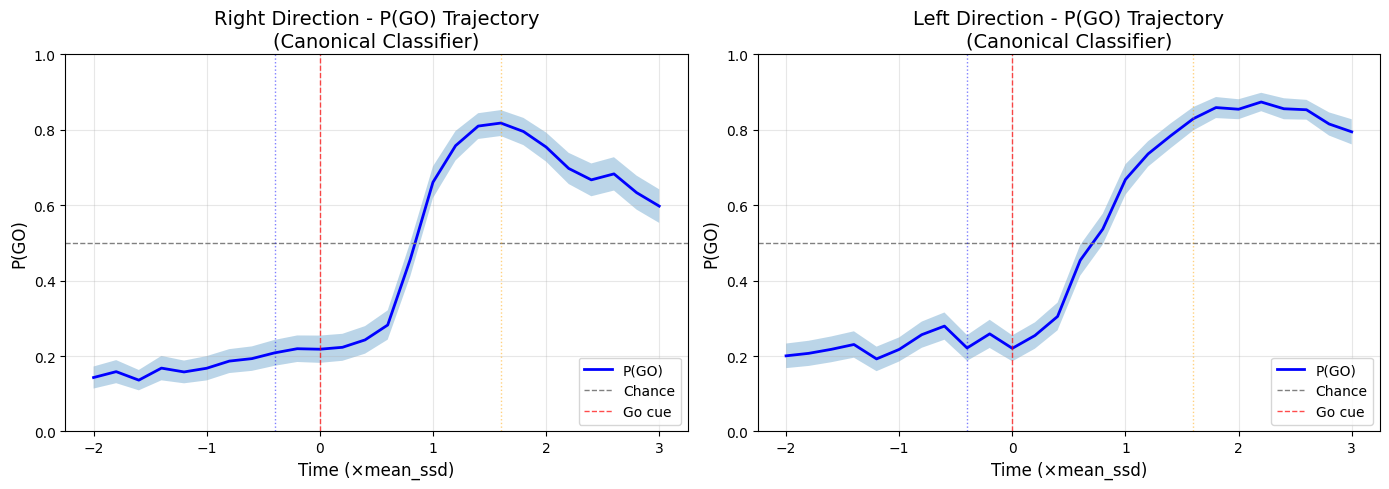


P(GO) at key timepoints:

Right Direction:
  t = -1.5×mean_ssd: P(GO) = 0.168
  t = -0.5×mean_ssd: P(GO) = 0.208
  t = +0.5×mean_ssd: P(GO) = 0.282
  t = +1.5×mean_ssd: P(GO) = 0.818
  t = +2.5×mean_ssd: P(GO) = 0.683

Left Direction:
  t = -1.5×mean_ssd: P(GO) = 0.231
  t = -0.5×mean_ssd: P(GO) = 0.221
  t = +0.5×mean_ssd: P(GO) = 0.454
  t = +1.5×mean_ssd: P(GO) = 0.829
  t = +2.5×mean_ssd: P(GO) = 0.853


In [15]:
# Plot P(GO) trajectory from canonical classifier
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, direction in enumerate(directions):
    ax = axes[idx]
    results = canonical_results[direction]

    window_mults = np.array(results['window_centers']) / results['mean_ssd']
    p_go = results['p_go_trajectory']
    p_go_err = results['p_go_std'] / np.sqrt(len(results['test_idx']))  # SEM

    # Plot P(GO) with error band
    ax.plot(window_mults, p_go, 'b-', linewidth=2, label='P(GO)')
    ax.fill_between(window_mults, p_go - p_go_err, p_go + p_go_err, alpha=0.3)

    # Reference lines
    ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=1, label='Chance')
    ax.axvline(x=0, color='red', linestyle='--', linewidth=1, alpha=0.7, label='Go cue')

    # Mark training windows
    fix_idx = results['fix_window_idx']
    go_idx = results['go_window_idx']
    ax.axvline(x=window_mults[fix_idx], color='blue', linestyle=':', linewidth=1, alpha=0.5)
    ax.axvline(x=window_mults[go_idx], color='orange', linestyle=':', linewidth=1, alpha=0.5)

    ax.set_xlabel('Time (×mean_ssd)', fontsize=12)
    ax.set_ylabel('P(GO)', fontsize=12)
    ax.set_title(f'{dir_map[direction]} Direction - P(GO) Trajectory\n(Canonical Classifier)', fontsize=14)
    ax.set_ylim(0.0, 1.0)
    ax.legend(loc='lower right')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print key timepoints
print("\nP(GO) at key timepoints:")
for direction in directions:
    results = canonical_results[direction]
    window_mults = np.array(results['window_centers']) / results['mean_ssd']
    p_go = results['p_go_trajectory']

    print(f"\n{dir_map[direction]} Direction:")
    for mult in [-1.5, -0.5, 0.5, 1.5, 2.5]:
        idx = np.argmin(np.abs(window_mults - mult))
        print(f"  t = {mult:+.1f}×mean_ssd: P(GO) = {p_go[idx]:.3f}")

---

# Part 2: Time-Binned Activity (PSTH Features)

Instead of using mean firing rate per epoch, we use binned spike counts to preserve temporal dynamics.
Feature vector: `[bin1_neuron1, bin1_neuron2, ..., bin2_neuron1, ...]`

In [16]:
def extract_binned_features(trial_data, epoch_start_ms, epoch_end_ms, 
                            cell_ids, bin_size_ms=25):
    """
    Extract time-binned spike count features.
    
    Parameters:
    -----------
    trial_data : DataFrame
        Filtered trial data (all cells for multiple trials)
    epoch_start_ms, epoch_end_ms : float
        Epoch boundaries (ms relative to go_cue)
    cell_ids : list
        Ordered list of cell IDs
    bin_size_ms : float
        Bin size in ms
    
    Returns:
    --------
    X : ndarray (n_trials, n_neurons * n_bins)
        Feature matrix (binned spike counts per neuron)
    bin_edges : ndarray
        Bin edge times
    trial_numbers : list
        Trial numbers corresponding to rows
    """
    trial_numbers = sorted(trial_data['trial_number'].unique())
    n_trials = len(trial_numbers)
    n_neurons = len(cell_ids)
    
    # Create bin edges
    bin_edges = np.arange(epoch_start_ms, epoch_end_ms + bin_size_ms, bin_size_ms)
    n_bins = len(bin_edges) - 1
    
    # Feature matrix: neurons × bins flattened
    X = np.zeros((n_trials, n_neurons * n_bins))
    
    for trial_idx, trial_num in enumerate(trial_numbers):
        trial_cells = trial_data[trial_data['trial_number'] == trial_num]
        
        for _, cell_row in trial_cells.iterrows():
            cell_id = cell_row['cell_ID']
            if cell_id not in cell_ids:
                continue
            
            neuron_idx = cell_ids.index(cell_id)
            
            # Get spike times relative to go_cue
            spike_times = np.array(cell_row['neural_data'], dtype=np.float64)
            go_cue = cell_row['go_cue']
            relative_spikes = spike_times - go_cue
            
            # Bin spike counts
            counts, _ = np.histogram(relative_spikes, bins=bin_edges)
            
            # Convert to firing rate (Hz)
            rates = counts / (bin_size_ms / 1000.0)
            
            # Store in feature matrix (neuron-major order)
            for bin_idx in range(n_bins):
                feature_idx = neuron_idx * n_bins + bin_idx
                X[trial_idx, feature_idx] = rates[bin_idx]
    
    return X, bin_edges, trial_numbers


print(f"✓ Binned feature extraction function defined (bin size: {BIN_SIZE_MS}ms)")

✓ Binned feature extraction function defined (bin size: 25ms)


In [17]:
# Define epochs for time-binned analysis (same as Phase 1)
EPOCH_DEFS_BINNED = [
    ('FIX_early', -2, -1, 0),  # (name, start_mult, end_mult, label: 0=FIX, 1=GO)
    ('FIX_late', -1, 0, 0),
    ('GO_early', 0, 1, 1),
    ('GO_late', 1, 2, 1),
]


def build_binned_dataset(trial_data, epoch_defs, mean_ssd, cell_ids, bin_size_ms=25):
    """
    Build time-binned feature dataset for decoder training.
    
    Each sample is a (trial, epoch) pair.
    Features: binned spike rates (neurons × bins).
    """
    all_X = []
    all_y = []
    all_meta = []
    
    for epoch_name, start_mult, end_mult, label in epoch_defs:
        epoch_start = start_mult * mean_ssd
        epoch_end = end_mult * mean_ssd
        
        X, bin_edges, trial_numbers = extract_binned_features(
            trial_data, epoch_start, epoch_end, cell_ids, bin_size_ms
        )
        
        n_trials = len(trial_numbers)
        y = np.full(n_trials, label)
        
        all_X.append(X)
        all_y.append(y)
        
        for trial_num in trial_numbers:
            all_meta.append({
                'trial_number': trial_num,
                'epoch_name': epoch_name,
                'label': label,
                'label_name': 'FIX' if label == 0 else 'GO'
            })
    
    X_combined = np.vstack(all_X)
    y_combined = np.concatenate(all_y)
    meta_df = pd.DataFrame(all_meta)
    
    # Store bin info
    n_bins_per_epoch = len(bin_edges) - 1
    
    return X_combined, y_combined, meta_df, n_bins_per_epoch, bin_edges


# Build binned datasets
binned_datasets = {}

print("Building time-binned datasets...")
print("=" * 60)

for direction in directions:
    print(f"\n{dir_map[direction]} Direction ({direction}°):")
    
    trial_data = filtered_data_by_dir[direction]
    mean_ssd = mean_ssd_dict[direction]
    cell_ids = sorted(trial_data['cell_ID'].unique())
    
    X, y, meta, n_bins, bin_edges = build_binned_dataset(
        trial_data, EPOCH_DEFS_BINNED, mean_ssd, cell_ids, BIN_SIZE_MS
    )
    
    print(f"  Samples: {len(X)}")
    print(f"  Neurons: {len(cell_ids)}")
    print(f"  Bins per epoch: {n_bins}")
    print(f"  Features per sample: {X.shape[1]} (neurons × bins)")
    print(f"  FIX samples: {(y == 0).sum()}, GO samples: {(y == 1).sum()}")
    
    binned_datasets[direction] = {
        'X': X,
        'y': y,
        'meta': meta,
        'cell_ids': cell_ids,
        'n_bins': n_bins,
        'bin_edges': bin_edges,
        'mean_ssd': mean_ssd
    }

Building time-binned datasets...

Right Direction (0°):


  Samples: 1740
  Neurons: 150
  Bins per epoch: 5
  Features per sample: 750 (neurons × bins)
  FIX samples: 870, GO samples: 870

Left Direction (180°):
  Samples: 1796
  Neurons: 150
  Bins per epoch: 5
  Features per sample: 750 (neurons × bins)
  FIX samples: 898, GO samples: 898


In [18]:
# Train and evaluate time-binned decoder
binned_results = {}

print("Training time-binned decoders...")
print("=" * 60)

for direction in directions:
    print(f"\n{dir_map[direction]} Direction ({direction}°):")
    print("-" * 40)
    
    dataset = binned_datasets[direction]
    X = dataset['X']
    y = dataset['y']
    meta = dataset['meta']
    
    # Train/test split
    X_train, X_test, y_train, y_test, meta_train, meta_test = train_test_split(
        X, y, meta,
        test_size=TEST_SIZE,
        stratify=y,
        random_state=RANDOM_STATE
    )
    
    # Normalize
    neuron_mean = X_train.mean(axis=0)
    neuron_std = X_train.std(axis=0)
    neuron_std[neuron_std == 0] = 1.0
    
    X_train_norm = (X_train - neuron_mean) / neuron_std
    X_test_norm = (X_test - neuron_mean) / neuron_std
    
    # Train logistic regression
    clf = LogisticRegression(
        penalty='l2', C=1.0, solver='lbfgs', max_iter=1000,
        class_weight='balanced', random_state=RANDOM_STATE
    )
    clf.fit(X_train_norm, y_train)
    
    # Evaluate
    y_pred = clf.predict(X_test_norm)
    y_prob = clf.predict_proba(X_test_norm)[:, 1]
    
    accuracy = accuracy_score(y_test, y_pred)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    
    print(f"  Training samples: {len(X_train)}")
    print(f"  Test samples: {len(X_test)}")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Balanced Accuracy: {balanced_acc:.4f}")
    print(f"  AUC-ROC: {auc:.4f}")
    
    # Per-epoch accuracy
    print(f"\n  Per-epoch accuracy:")
    for epoch_name in ['FIX_early', 'FIX_late', 'GO_early', 'GO_late']:
        epoch_mask = meta_test['epoch_name'] == epoch_name
        if epoch_mask.sum() > 0:
            epoch_acc = accuracy_score(y_test[epoch_mask.values], y_pred[epoch_mask.values])
            print(f"    {epoch_name}: {epoch_acc:.3f}")
    
    binned_results[direction] = {
        'model': clf,
        'accuracy': accuracy,
        'balanced_accuracy': balanced_acc,
        'auc_roc': auc,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'y_test': y_test,
        'meta_test': meta_test,
        'neuron_mean': neuron_mean,
        'neuron_std': neuron_std
    }

Training time-binned decoders...

Right Direction (0°):
----------------------------------------


/home/barak/Projects/population-analysis/.conda/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


  Training samples: 1392
  Test samples: 348
  Accuracy: 0.7557
  Balanced Accuracy: 0.7557
  AUC-ROC: 0.8158

  Per-epoch accuracy:
    FIX_early: 0.798
    FIX_late: 0.800
    GO_early: 0.570
    GO_late: 0.852

Left Direction (180°):
----------------------------------------


/home/barak/Projects/population-analysis/.conda/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


  Training samples: 1436
  Test samples: 360
  Accuracy: 0.7361
  Balanced Accuracy: 0.7361
  AUC-ROC: 0.8034

  Per-epoch accuracy:
    FIX_early: 0.776
    FIX_late: 0.716
    GO_early: 0.640
    GO_late: 0.809


In [19]:
# Compare with mean FR decoder (load from Phase 2 results)
print("\n" + "=" * 60)
print("COMPARISON: Time-Binned vs Mean FR Decoder")
print("=" * 60)

# Load Phase 2 results if available
results_file = Path.cwd().parents[1] / 'data' / 'decoder_models' / f'results_summary_{SESSION_ID}_ssd{SSD_NUM}.pkl'

if results_file.exists():
    with open(results_file, 'rb') as f:
        phase2_results = pickle.load(f)
    
    print(f"\n{'Direction':<10} {'Model':<20} {'Accuracy':<12} {'AUC-ROC':<12}")
    print("-" * 60)
    
    for direction in directions:
        # Mean FR decoder (Phase 2)
        lr_acc = float(phase2_results['lr_results'][direction]['accuracy'])
        lr_auc = float(phase2_results['lr_results'][direction]['auc_roc'])
        print(f"{dir_map[direction]:<10} {'Mean FR (LR)':<20} {lr_acc:<12.4f} {lr_auc:<12.4f}")
        
        # Time-binned decoder
        binned_acc = binned_results[direction]['accuracy']
        binned_auc = binned_results[direction]['auc_roc']
        print(f"{'':<10} {'Time-Binned (LR)':<20} {binned_acc:<12.4f} {binned_auc:<12.4f}")
        print()
else:
    print("Phase 2 results not found. Run xie_decoder_phase2.ipynb first for comparison.")
    
    print(f"\n{'Direction':<10} {'Model':<20} {'Accuracy':<12} {'AUC-ROC':<12}")
    print("-" * 60)
    for direction in directions:
        binned_acc = binned_results[direction]['accuracy']
        binned_auc = binned_results[direction]['auc_roc']
        print(f"{dir_map[direction]:<10} {'Time-Binned (LR)':<20} {binned_acc:<12.4f} {binned_auc:<12.4f}")


COMPARISON: Time-Binned vs Mean FR Decoder

Direction  Model                Accuracy     AUC-ROC     
------------------------------------------------------------
Right      Mean FR (LR)         0.8908       0.9597      
           Time-Binned (LR)     0.7557       0.8158      

Left       Mean FR (LR)         0.8222       0.9204      
           Time-Binned (LR)     0.7361       0.8034      



## Summary and Interpretation

In [20]:
print("\n" + "=" * 80)
print("SUMMARY: Temporal Analysis Results")
print("=" * 80)

print("\n1. CROSS-TEMPORAL GENERALIZATION")
print("-" * 40)
for direction in directions:
    results = cross_temporal_results[direction]
    diag = np.diag(results['accuracy_matrix'])
    off_diag = results['accuracy_matrix'][~np.eye(len(diag), dtype=bool)]

    print(f"\n{dir_map[direction]} Direction:")
    print(f"  Diagonal (same-time) accuracy: {diag.mean():.3f} ± {diag.std():.3f}")
    print(f"  Off-diagonal (cross-time) accuracy: {off_diag.mean():.3f} ± {off_diag.std():.3f}")
    print(f"  Temporal stability ratio: {off_diag.mean() / diag.mean():.2f}")

print("\n2. CANONICAL CLASSIFIER P(GO) TRAJECTORY")
print("-" * 40)
for direction in directions:
    results = canonical_results[direction]
    window_mults = np.array(results['window_centers']) / results['mean_ssd']
    p_go = results['p_go_trajectory']

    print(f"\n{dir_map[direction]} Direction:")
    for mult in [-1.5, 0.0, 1.0, 2.0]:
        idx = np.argmin(np.abs(window_mults - mult))
        print(f"  t = {mult:+.1f}×mean_ssd: P(GO) = {p_go[idx]:.3f}")

print("\n3. TIME-BINNED DECODER PERFORMANCE")
print("-" * 40)
for direction in directions:
    results = binned_results[direction]
    print(f"\n{dir_map[direction]} Direction:")
    print(f"  Accuracy: {results['accuracy']:.4f}")
    print(f"  AUC-ROC: {results['auc_roc']:.4f}")

print("\n" + "=" * 80)
print("KEY INSIGHTS:")
print("=" * 80)
print("""
Cross-Temporal Matrix Interpretation:
- Strong diagonal: Decoder trained at time t works best at time t
- Off-diagonal structure: Reveals how stable neural representations are
- Block structure (if present): FIX and GO may have different dynamics

P(GO) Trajectory (Canonical Classifier):
- Shows how the neural state transitions from FIX to GO over time
- Gradual increase around go_cue suggests continuous transition
- Sharp transitions suggest discrete state changes

Time-Binned vs Mean FR:
- Similar performance: Temporal dynamics within epochs not critical
- Higher performance: Temporal patterns matter for classification
""")


SUMMARY: Temporal Analysis Results

1. CROSS-TEMPORAL GENERALIZATION
----------------------------------------

Right Direction:
  Diagonal (same-time) accuracy: 0.744 ± 0.133
  Off-diagonal (cross-time) accuracy: 0.686 ± 0.168
  Temporal stability ratio: 0.92

Left Direction:
  Diagonal (same-time) accuracy: 0.762 ± 0.157
  Off-diagonal (cross-time) accuracy: 0.715 ± 0.171
  Temporal stability ratio: 0.94

2. CANONICAL CLASSIFIER P(GO) TRAJECTORY
----------------------------------------

Right Direction:
  t = -1.5×mean_ssd: P(GO) = 0.168
  t = +0.0×mean_ssd: P(GO) = 0.218
  t = +1.0×mean_ssd: P(GO) = 0.661
  t = +2.0×mean_ssd: P(GO) = 0.754

Left Direction:
  t = -1.5×mean_ssd: P(GO) = 0.231
  t = +0.0×mean_ssd: P(GO) = 0.220
  t = +1.0×mean_ssd: P(GO) = 0.668
  t = +2.0×mean_ssd: P(GO) = 0.854

3. TIME-BINNED DECODER PERFORMANCE
----------------------------------------

Right Direction:
  Accuracy: 0.7557
  AUC-ROC: 0.8158

Left Direction:
  Accuracy: 0.7361
  AUC-ROC: 0.8034

KEY I

---

# Part 3: STOP Trial Analysis

Apply the trained canonical classifier to STOP trials to see how they evolve in the FIX/GO space over time. Compare with GO and CONT trials.

In [21]:
# Filter STOP and CONT trials (successful, SSD2)
def filter_stop_cont_trials(session_data, direction, trial_type, ssd_number=2):
    """Filter STOP or CONT trials: successful with specific SSD."""
    mask = (
        (session_data['type'] == trial_type) &
        (session_data['dir'] == direction) &
        (session_data['trial_failed'] == False) &
        (session_data['ssd_number'] == ssd_number)
    )
    return session_data[mask].copy()


# Get STOP and CONT trials for each direction
stop_data_by_dir = {}
cont_data_by_dir = {}

print("Filtering STOP and CONT trials...")
print("=" * 60)

for direction in directions:
    # STOP trials
    stop_trials = filter_stop_cont_trials(session.data, direction, 'STOP', SSD_NUM)
    stop_data_by_dir[direction] = stop_trials
    n_stop = len(stop_trials['trial_number'].unique())
    
    # CONT trials
    cont_trials = filter_stop_cont_trials(session.data, direction, 'CONT', SSD_NUM)
    cont_data_by_dir[direction] = cont_trials
    n_cont = len(cont_trials['trial_number'].unique())
    
    print(f"\n{dir_map[direction]} Direction ({direction}°):")
    print(f"  STOP trials (successful, SSD{SSD_NUM}): {n_stop}")
    print(f"  CONT trials (successful, SSD{SSD_NUM}): {n_cont}")

Filtering STOP and CONT trials...

Right Direction (0°):
  STOP trials (successful, SSD2): 40
  CONT trials (successful, SSD2): 36

Left Direction (180°):
  STOP trials (successful, SSD2): 37
  CONT trials (successful, SSD2): 60


In [22]:
def extract_trial_features_all_windows(trial_data, window_centers, window_width, cell_ids):
    """
    Extract features for each trial at all time windows.
    
    Returns:
    --------
    trial_features : dict
        {trial_number: ndarray (n_windows, n_neurons)}
    """
    trial_numbers = sorted(trial_data['trial_number'].unique())
    n_windows = len(window_centers)
    n_neurons = len(cell_ids)
    
    trial_features = {}
    
    for trial_num in trial_numbers:
        trial_cells = trial_data[trial_data['trial_number'] == trial_num]
        X_trial = np.zeros((n_windows, n_neurons))
        
        for window_idx, center_ms in enumerate(window_centers):
            window_start = center_ms - window_width / 2
            window_end = center_ms + window_width / 2
            duration_sec = window_width / 1000.0
            
            for _, cell_row in trial_cells.iterrows():
                cell_id = cell_row['cell_ID']
                if cell_id not in cell_ids:
                    continue
                
                neuron_idx = cell_ids.index(cell_id)
                
                # Get spike times relative to go_cue
                spike_times = np.array(cell_row['neural_data'], dtype=np.float64)
                go_cue = cell_row['go_cue']
                relative_spikes = spike_times - go_cue
                
                # Count spikes in window
                spikes_in_window = relative_spikes[
                    (relative_spikes >= window_start) & (relative_spikes < window_end)
                ]
                
                X_trial[window_idx, neuron_idx] = len(spikes_in_window) / duration_sec
        
        trial_features[trial_num] = X_trial
    
    return trial_features


def apply_classifier_to_trials(trial_features, model, neuron_mean, neuron_std):
    """
    Apply classifier to get P(GO) for each trial at each time window.
    
    Returns:
    --------
    p_go_matrix : ndarray (n_trials, n_windows)
        P(GO) for each trial at each time point
    trial_numbers : list
        Trial numbers in order
    """
    trial_numbers = sorted(trial_features.keys())
    n_trials = len(trial_numbers)
    n_windows = trial_features[trial_numbers[0]].shape[0]
    
    p_go_matrix = np.zeros((n_trials, n_windows))
    
    for trial_idx, trial_num in enumerate(trial_numbers):
        X_trial = trial_features[trial_num]
        
        # Normalize using training statistics
        X_norm = (X_trial - neuron_mean) / neuron_std
        
        # Get P(GO) at each time point
        p_go = model.predict_proba(X_norm)[:, 1]
        p_go_matrix[trial_idx, :] = p_go
    
    return p_go_matrix, trial_numbers


print("✓ Trial-level feature extraction functions defined")

✓ Trial-level feature extraction functions defined


In [23]:
# Extract features and apply classifier to STOP, CONT, and GO trials
stop_results = {}
cont_results = {}
go_results = {}

print("Extracting features and classifying trials...")
print("=" * 60)

for direction in directions:
    print(f"\n{dir_map[direction]} Direction ({direction}°):")
    print("-" * 40)
    
    # Get canonical classifier and normalization parameters
    canon = canonical_results[direction]
    model = canon['model']
    neuron_mean = canon['neuron_mean']
    neuron_std = canon['neuron_std']
    
    # Get window parameters
    window_centers = canon['window_centers']
    mean_ssd = canon['mean_ssd']
    window_width = WINDOW_WIDTH_MULT * mean_ssd
    
    # Get cell IDs from the sliding window data
    cell_ids = sliding_data_by_dir[direction]['cell_ids']
    
    # --- STOP trials ---
    print("  Processing STOP trials...")
    stop_features = extract_trial_features_all_windows(
        stop_data_by_dir[direction], window_centers, window_width, cell_ids
    )
    stop_p_go, stop_trial_nums = apply_classifier_to_trials(
        stop_features, model, neuron_mean, neuron_std
    )
    stop_results[direction] = {
        'p_go_matrix': stop_p_go,
        'trial_numbers': stop_trial_nums,
        'window_centers': window_centers,
        'mean_ssd': mean_ssd
    }
    print(f"    {len(stop_trial_nums)} trials processed")
    
    # --- CONT trials ---
    print("  Processing CONT trials...")
    cont_features = extract_trial_features_all_windows(
        cont_data_by_dir[direction], window_centers, window_width, cell_ids
    )
    cont_p_go, cont_trial_nums = apply_classifier_to_trials(
        cont_features, model, neuron_mean, neuron_std
    )
    cont_results[direction] = {
        'p_go_matrix': cont_p_go,
        'trial_numbers': cont_trial_nums,
        'window_centers': window_centers,
        'mean_ssd': mean_ssd
    }
    print(f"    {len(cont_trial_nums)} trials processed")
    
    # --- GO trials (use test set from canonical classifier) ---
    print("  Processing GO trials (test set)...")
    test_idx = canon['test_idx']
    window_data = sliding_data_by_dir[direction]['window_data']
    
    # Reconstruct P(GO) for GO test trials at each time window
    go_trial_numbers = [window_data[0]['trial_numbers'][i] for i in test_idx]
    n_go_trials = len(go_trial_numbers)
    n_windows = len(window_centers)
    
    go_p_go = np.zeros((n_go_trials, n_windows))
    for window_idx in range(n_windows):
        X_window = window_data[window_idx]['X'][test_idx]
        X_norm = (X_window - neuron_mean) / neuron_std
        go_p_go[:, window_idx] = model.predict_proba(X_norm)[:, 1]
    
    go_results[direction] = {
        'p_go_matrix': go_p_go,
        'trial_numbers': go_trial_numbers,
        'window_centers': window_centers,
        'mean_ssd': mean_ssd
    }
    print(f"    {n_go_trials} trials processed")

print("\n✓ All trials classified")

Extracting features and classifying trials...

Right Direction (0°):
----------------------------------------
  Processing STOP trials...
    40 trials processed
  Processing CONT trials...
    36 trials processed
  Processing GO trials (test set)...
    87 trials processed

Left Direction (180°):
----------------------------------------
  Processing STOP trials...
    37 trials processed
  Processing CONT trials...
    60 trials processed
  Processing GO trials (test set)...
    90 trials processed

✓ All trials classified


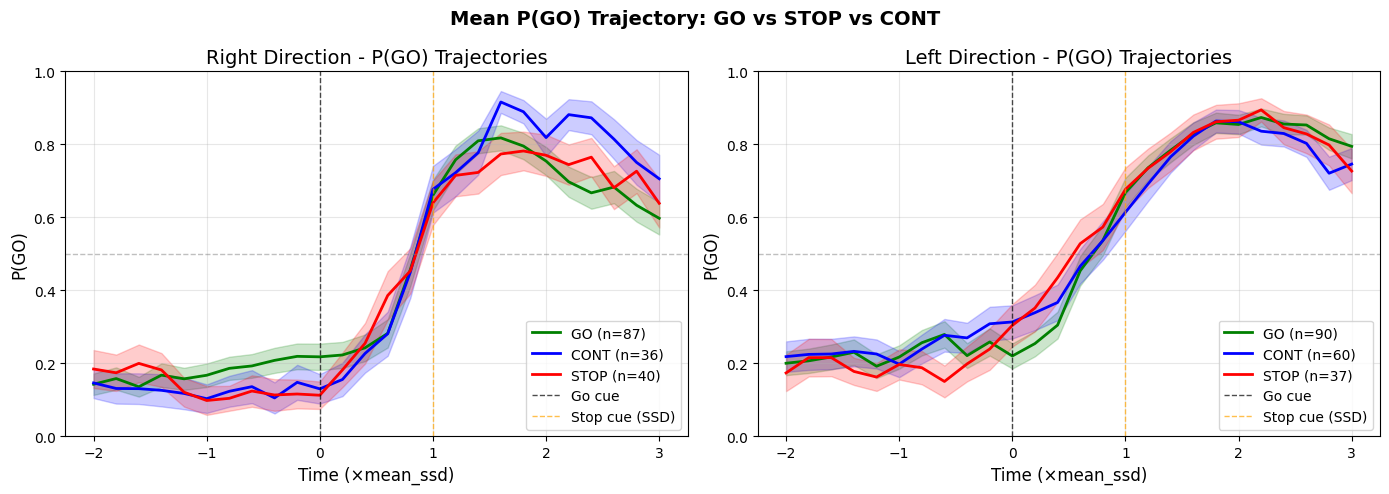


Mean P(GO) at key timepoints:

Right Direction:
Time            GO         CONT       STOP      
---------------------------------------------
-1.0×mean_ssd    0.168     0.103     0.098
+0.0×mean_ssd    0.218     0.130     0.113
+0.5×mean_ssd    0.282     0.281     0.386
+1.0×mean_ssd    0.661     0.677     0.640
+1.5×mean_ssd    0.818     0.916     0.774
+2.0×mean_ssd    0.754     0.819     0.770

Left Direction:
Time            GO         CONT       STOP      
---------------------------------------------
-1.0×mean_ssd    0.218     0.198     0.197
+0.0×mean_ssd    0.220     0.314     0.304
+0.5×mean_ssd    0.454     0.466     0.528
+1.0×mean_ssd    0.668     0.614     0.677
+1.5×mean_ssd    0.829     0.822     0.833
+2.0×mean_ssd    0.854     0.862     0.866


In [24]:
# Plot mean P(GO) trajectories for STOP, CONT, and GO trials
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, direction in enumerate(directions):
    ax = axes[idx]
    mean_ssd = stop_results[direction]['mean_ssd']
    window_centers = stop_results[direction]['window_centers']
    window_mults = np.array(window_centers) / mean_ssd
    
    # GO trials
    go_p_go = go_results[direction]['p_go_matrix']
    go_mean = go_p_go.mean(axis=0)
    go_sem = go_p_go.std(axis=0) / np.sqrt(go_p_go.shape[0])
    ax.plot(window_mults, go_mean, 'g-', linewidth=2, label=f'GO (n={go_p_go.shape[0]})')
    ax.fill_between(window_mults, go_mean - go_sem, go_mean + go_sem, color='green', alpha=0.2)
    
    # CONT trials
    cont_p_go = cont_results[direction]['p_go_matrix']
    cont_mean = cont_p_go.mean(axis=0)
    cont_sem = cont_p_go.std(axis=0) / np.sqrt(cont_p_go.shape[0])
    ax.plot(window_mults, cont_mean, 'b-', linewidth=2, label=f'CONT (n={cont_p_go.shape[0]})')
    ax.fill_between(window_mults, cont_mean - cont_sem, cont_mean + cont_sem, color='blue', alpha=0.2)
    
    # STOP trials
    stop_p_go = stop_results[direction]['p_go_matrix']
    stop_mean = stop_p_go.mean(axis=0)
    stop_sem = stop_p_go.std(axis=0) / np.sqrt(stop_p_go.shape[0])
    ax.plot(window_mults, stop_mean, 'r-', linewidth=2, label=f'STOP (n={stop_p_go.shape[0]})')
    ax.fill_between(window_mults, stop_mean - stop_sem, stop_mean + stop_sem, color='red', alpha=0.2)
    
    # Reference lines
    ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    ax.axvline(x=0, color='black', linestyle='--', linewidth=1, alpha=0.7, label='Go cue')
    ax.axvline(x=1, color='orange', linestyle='--', linewidth=1, alpha=0.7, label='Stop cue (SSD)')
    
    ax.set_xlabel('Time (×mean_ssd)', fontsize=12)
    ax.set_ylabel('P(GO)', fontsize=12)
    ax.set_title(f'{dir_map[direction]} Direction - P(GO) Trajectories', fontsize=14)
    ax.set_ylim(0.0, 1.0)
    ax.legend(loc='lower right')
    ax.grid(alpha=0.3)

plt.suptitle('Mean P(GO) Trajectory: GO vs STOP vs CONT', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print key values
print("\nMean P(GO) at key timepoints:")
for direction in directions:
    window_mults = np.array(stop_results[direction]['window_centers']) / stop_results[direction]['mean_ssd']
    
    print(f"\n{dir_map[direction]} Direction:")
    print(f"{'Time':<15} {'GO':<10} {'CONT':<10} {'STOP':<10}")
    print("-" * 45)
    
    for mult in [-1.0, 0.0, 0.5, 1.0, 1.5, 2.0]:
        idx = np.argmin(np.abs(window_mults - mult))
        go_val = go_results[direction]['p_go_matrix'][:, idx].mean()
        cont_val = cont_results[direction]['p_go_matrix'][:, idx].mean()
        stop_val = stop_results[direction]['p_go_matrix'][:, idx].mean()
        print(f"{mult:+.1f}×mean_ssd    {go_val:.3f}     {cont_val:.3f}     {stop_val:.3f}")

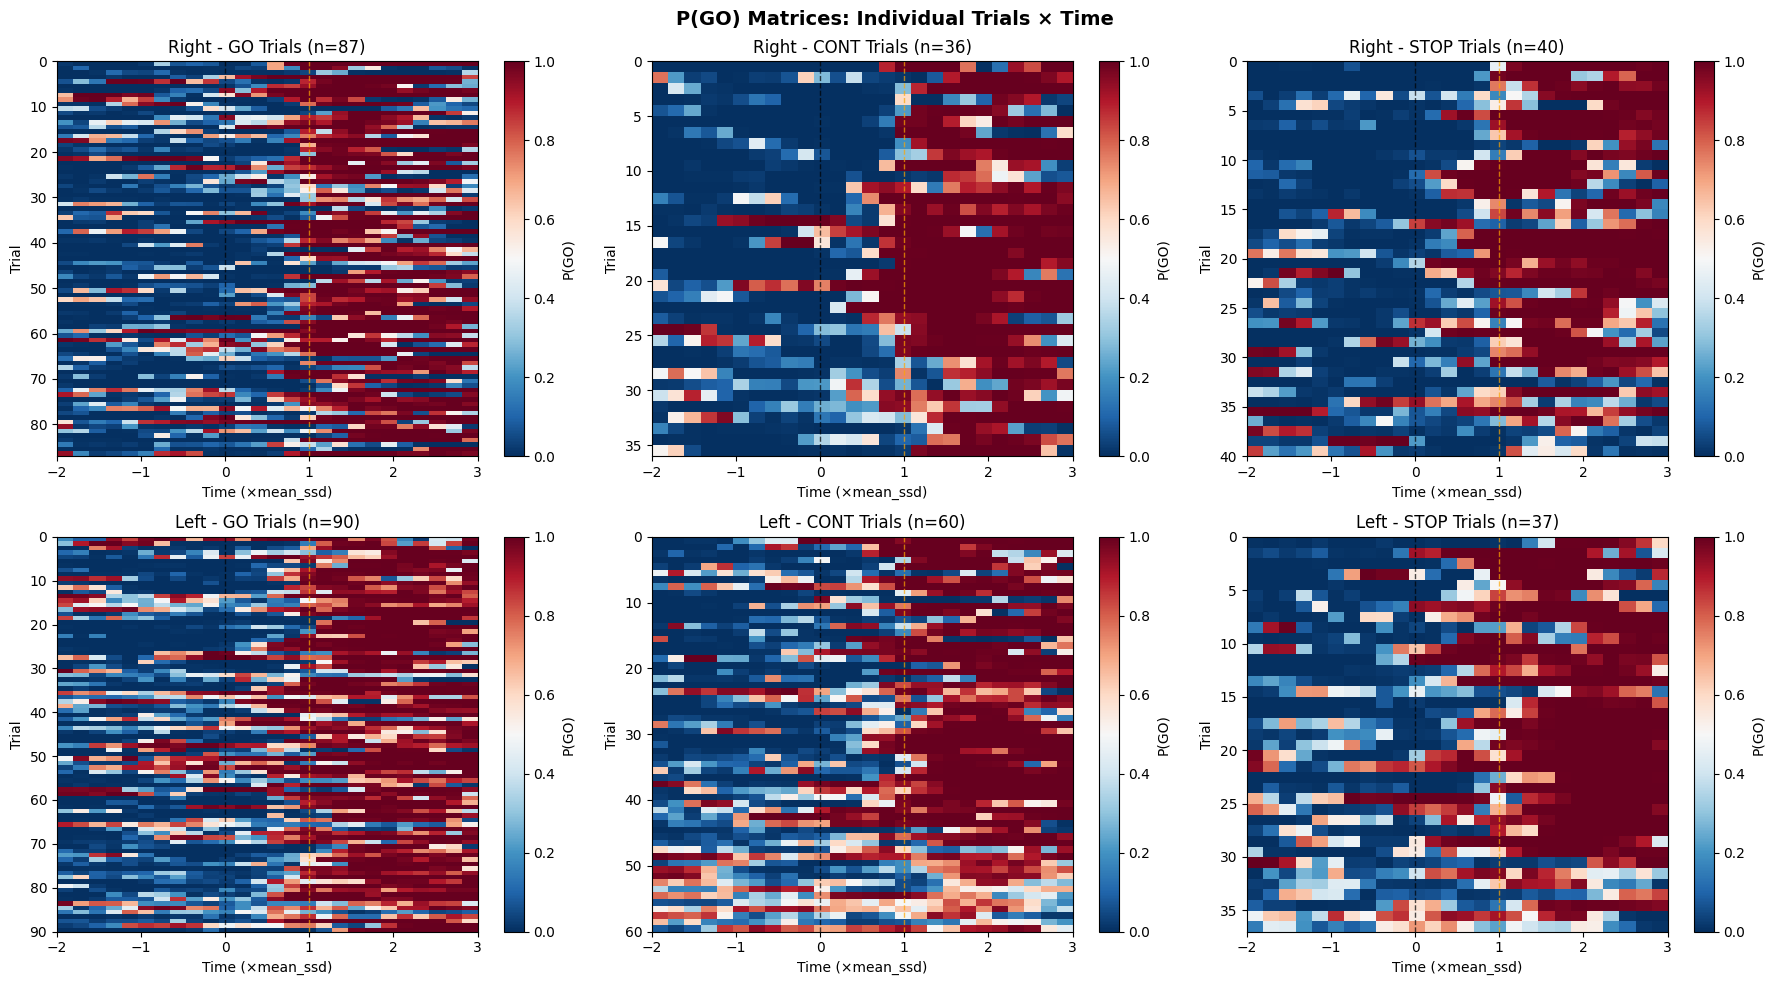

In [25]:
# Plot P(GO) matrices for individual trials (trials × time)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, direction in enumerate(directions):
    mean_ssd = stop_results[direction]['mean_ssd']
    window_centers = stop_results[direction]['window_centers']
    window_mults = np.array(window_centers) / mean_ssd
    
    # GO trials
    ax = axes[idx, 0]
    go_matrix = go_results[direction]['p_go_matrix']
    im = ax.imshow(go_matrix, cmap='RdBu_r', aspect='auto', vmin=0, vmax=1,
                   extent=[window_mults[0], window_mults[-1], go_matrix.shape[0], 0])
    ax.axvline(x=0, color='black', linestyle='--', linewidth=1, alpha=0.7)
    ax.axvline(x=1, color='orange', linestyle='--', linewidth=1, alpha=0.7)
    ax.set_xlabel('Time (×mean_ssd)')
    ax.set_ylabel('Trial')
    ax.set_title(f'{dir_map[direction]} - GO Trials (n={go_matrix.shape[0]})')
    plt.colorbar(im, ax=ax, label='P(GO)')
    
    # CONT trials
    ax = axes[idx, 1]
    cont_matrix = cont_results[direction]['p_go_matrix']
    im = ax.imshow(cont_matrix, cmap='RdBu_r', aspect='auto', vmin=0, vmax=1,
                   extent=[window_mults[0], window_mults[-1], cont_matrix.shape[0], 0])
    ax.axvline(x=0, color='black', linestyle='--', linewidth=1, alpha=0.7)
    ax.axvline(x=1, color='orange', linestyle='--', linewidth=1, alpha=0.7)
    ax.set_xlabel('Time (×mean_ssd)')
    ax.set_ylabel('Trial')
    ax.set_title(f'{dir_map[direction]} - CONT Trials (n={cont_matrix.shape[0]})')
    plt.colorbar(im, ax=ax, label='P(GO)')
    
    # STOP trials
    ax = axes[idx, 2]
    stop_matrix = stop_results[direction]['p_go_matrix']
    im = ax.imshow(stop_matrix, cmap='RdBu_r', aspect='auto', vmin=0, vmax=1,
                   extent=[window_mults[0], window_mults[-1], stop_matrix.shape[0], 0])
    ax.axvline(x=0, color='black', linestyle='--', linewidth=1, alpha=0.7)
    ax.axvline(x=1, color='orange', linestyle='--', linewidth=1, alpha=0.7)
    ax.set_xlabel('Time (×mean_ssd)')
    ax.set_ylabel('Trial')
    ax.set_title(f'{dir_map[direction]} - STOP Trials (n={stop_matrix.shape[0]})')
    plt.colorbar(im, ax=ax, label='P(GO)')

plt.suptitle('P(GO) Matrices: Individual Trials × Time', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

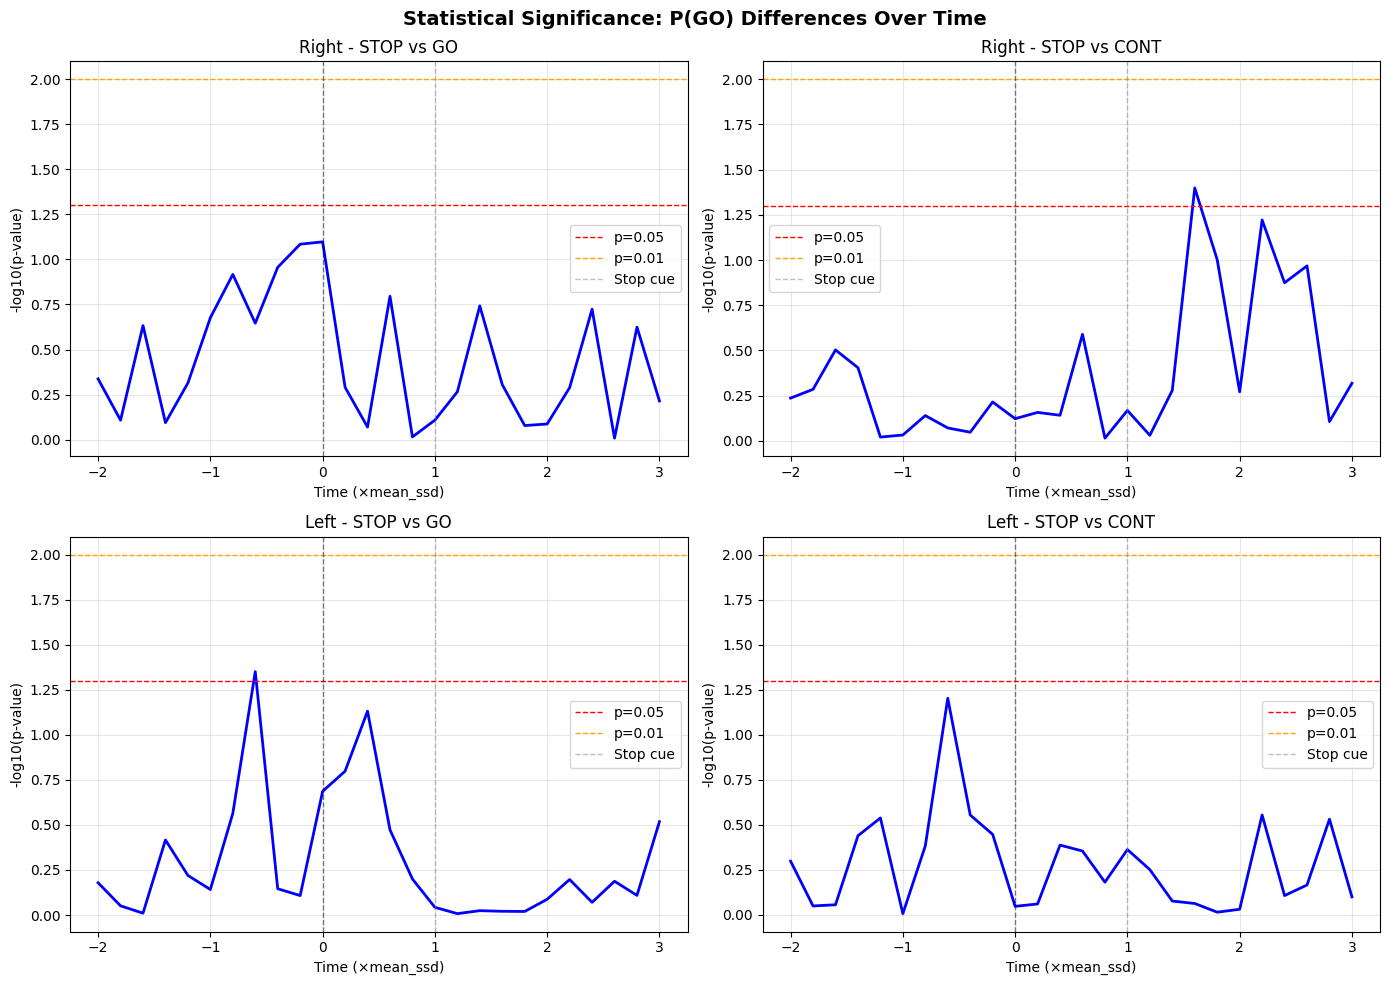


Significant differences (p < 0.05):

Right Direction:
  STOP vs GO: no significant differences
  STOP vs CONT: significant at t = [1.6]

Left Direction:
  STOP vs GO: significant at t = [-0.6]
  STOP vs CONT: no significant differences


In [26]:
# Statistical tests: Compare STOP vs GO and STOP vs CONT at each time point
from scipy import stats

def compute_pvalues_over_time(matrix1, matrix2, window_mults):
    """Compute t-test p-values comparing two conditions at each time point."""
    n_windows = matrix1.shape[1]
    p_values = np.zeros(n_windows)
    t_stats = np.zeros(n_windows)
    
    for i in range(n_windows):
        t, p = stats.ttest_ind(matrix1[:, i], matrix2[:, i])
        t_stats[i] = t
        p_values[i] = p
    
    return t_stats, p_values


# Plot statistical comparisons
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, direction in enumerate(directions):
    mean_ssd = stop_results[direction]['mean_ssd']
    window_centers = stop_results[direction]['window_centers']
    window_mults = np.array(window_centers) / mean_ssd
    
    go_matrix = go_results[direction]['p_go_matrix']
    cont_matrix = cont_results[direction]['p_go_matrix']
    stop_matrix = stop_results[direction]['p_go_matrix']
    
    # STOP vs GO
    ax = axes[idx, 0]
    t_stats_go, p_vals_go = compute_pvalues_over_time(stop_matrix, go_matrix, window_mults)
    
    # Plot -log10(p-value)
    neg_log_p = -np.log10(np.clip(p_vals_go, 1e-10, 1))
    ax.plot(window_mults, neg_log_p, 'b-', linewidth=2)
    ax.axhline(y=-np.log10(0.05), color='red', linestyle='--', linewidth=1, label='p=0.05')
    ax.axhline(y=-np.log10(0.01), color='orange', linestyle='--', linewidth=1, label='p=0.01')
    ax.axvline(x=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    ax.axvline(x=1, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='Stop cue')
    
    ax.set_xlabel('Time (×mean_ssd)')
    ax.set_ylabel('-log10(p-value)')
    ax.set_title(f'{dir_map[direction]} - STOP vs GO')
    ax.legend()
    ax.grid(alpha=0.3)
    
    # Mark significant time points
    sig_05 = p_vals_go < 0.05
    sig_01 = p_vals_go < 0.01
    
    # STOP vs CONT
    ax = axes[idx, 1]
    t_stats_cont, p_vals_cont = compute_pvalues_over_time(stop_matrix, cont_matrix, window_mults)
    
    neg_log_p = -np.log10(np.clip(p_vals_cont, 1e-10, 1))
    ax.plot(window_mults, neg_log_p, 'b-', linewidth=2)
    ax.axhline(y=-np.log10(0.05), color='red', linestyle='--', linewidth=1, label='p=0.05')
    ax.axhline(y=-np.log10(0.01), color='orange', linestyle='--', linewidth=1, label='p=0.01')
    ax.axvline(x=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    ax.axvline(x=1, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='Stop cue')
    
    ax.set_xlabel('Time (×mean_ssd)')
    ax.set_ylabel('-log10(p-value)')
    ax.set_title(f'{dir_map[direction]} - STOP vs CONT')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Statistical Significance: P(GO) Differences Over Time', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print significant time windows
print("\nSignificant differences (p < 0.05):")
for direction in directions:
    window_mults = np.array(stop_results[direction]['window_centers']) / stop_results[direction]['mean_ssd']
    
    go_matrix = go_results[direction]['p_go_matrix']
    cont_matrix = cont_results[direction]['p_go_matrix']
    stop_matrix = stop_results[direction]['p_go_matrix']
    
    _, p_vals_go = compute_pvalues_over_time(stop_matrix, go_matrix, window_mults)
    _, p_vals_cont = compute_pvalues_over_time(stop_matrix, cont_matrix, window_mults)
    
    print(f"\n{dir_map[direction]} Direction:")
    
    # STOP vs GO
    sig_windows_go = window_mults[p_vals_go < 0.05]
    if len(sig_windows_go) > 0:
        print(f"  STOP vs GO: significant at t = {sig_windows_go}")
    else:
        print(f"  STOP vs GO: no significant differences")
    
    # STOP vs CONT
    sig_windows_cont = window_mults[p_vals_cont < 0.05]
    if len(sig_windows_cont) > 0:
        print(f"  STOP vs CONT: significant at t = {sig_windows_cont}")
    else:
        print(f"  STOP vs CONT: no significant differences")

In [27]:
# Summary: STOP trial analysis
print("\n" + "=" * 80)
print("STOP TRIAL ANALYSIS SUMMARY")
print("=" * 80)

for direction in directions:
    mean_ssd = stop_results[direction]['mean_ssd']
    window_mults = np.array(stop_results[direction]['window_centers']) / mean_ssd
    
    go_matrix = go_results[direction]['p_go_matrix']
    cont_matrix = cont_results[direction]['p_go_matrix']
    stop_matrix = stop_results[direction]['p_go_matrix']
    
    print(f"\n{dir_map[direction]} Direction:")
    print("-" * 60)
    
    # Pre-signal period (between go_cue and stop_cue): 0 to 1×mean_ssd
    pre_signal_idx = (window_mults >= 0) & (window_mults <= 1)
    pre_signal_times = window_mults[pre_signal_idx]
    
    go_pre = go_matrix[:, pre_signal_idx].mean()
    cont_pre = cont_matrix[:, pre_signal_idx].mean()
    stop_pre = stop_matrix[:, pre_signal_idx].mean()
    
    print(f"\n  Pre-signal period (0 to 1×mean_ssd):")
    print(f"    GO:   P(GO) = {go_pre:.3f}")
    print(f"    CONT: P(GO) = {cont_pre:.3f}")
    print(f"    STOP: P(GO) = {stop_pre:.3f}")
    
    # Post-signal period (after stop_cue): 1 to 2×mean_ssd
    post_signal_idx = (window_mults >= 1) & (window_mults <= 2)
    
    go_post = go_matrix[:, post_signal_idx].mean()
    cont_post = cont_matrix[:, post_signal_idx].mean()
    stop_post = stop_matrix[:, post_signal_idx].mean()
    
    print(f"\n  Post-signal period (1 to 2×mean_ssd):")
    print(f"    GO:   P(GO) = {go_post:.3f}")
    print(f"    CONT: P(GO) = {cont_post:.3f}")
    print(f"    STOP: P(GO) = {stop_post:.3f}")
    
    # Change from pre to post
    print(f"\n  Change (post - pre):")
    print(f"    GO:   ΔP(GO) = {go_post - go_pre:+.3f}")
    print(f"    CONT: ΔP(GO) = {cont_post - cont_pre:+.3f}")
    print(f"    STOP: ΔP(GO) = {stop_post - stop_pre:+.3f}")
    
    # Late period: 2 to 3×mean_ssd
    late_idx = (window_mults >= 2) & (window_mults <= 3)
    
    go_late = go_matrix[:, late_idx].mean()
    cont_late = cont_matrix[:, late_idx].mean()
    stop_late = stop_matrix[:, late_idx].mean()
    
    print(f"\n  Late period (2 to 3×mean_ssd):")
    print(f"    GO:   P(GO) = {go_late:.3f}")
    print(f"    CONT: P(GO) = {cont_late:.3f}")
    print(f"    STOP: P(GO) = {stop_late:.3f}")

print("\n" + "=" * 80)
print("KEY FINDINGS:")
print("=" * 80)
print("""
1. PRE-SIGNAL PERIOD (0 to 1×mean_ssd):
   - All trial types should show similar intermediate P(GO)
   - This is before the stop/continue signal arrives

2. POST-SIGNAL PERIOD (1 to 2×mean_ssd):
   - GO trials: Continue increasing toward GO state
   - CONT trials: Should match GO (same motor outcome)
   - STOP trials: The key question - do they diverge?

3. INTERPRETATION:
   - If STOP P(GO) stays low: Stopping = maintaining FIX state
   - If STOP P(GO) matches GO/CONT: Stopping not visible in FIX/GO axis
   - If STOP P(GO) is intermediate: Partial GO preparation that gets interrupted
""")


STOP TRIAL ANALYSIS SUMMARY

Right Direction:
------------------------------------------------------------

  Pre-signal period (0 to 1×mean_ssd):
    GO:   P(GO) = 0.373
    CONT: P(GO) = 0.358
    STOP: P(GO) = 0.383

  Post-signal period (1 to 2×mean_ssd):
    GO:   P(GO) = 0.787
    CONT: P(GO) = 0.825
    STOP: P(GO) = 0.753

  Change (post - pre):
    GO:   ΔP(GO) = +0.414
    CONT: ΔP(GO) = +0.466
    STOP: ΔP(GO) = +0.369

  Late period (2 to 3×mean_ssd):
    GO:   P(GO) = 0.656
    CONT: P(GO) = 0.805
    STOP: P(GO) = 0.711

Left Direction:
------------------------------------------------------------

  Pre-signal period (0 to 1×mean_ssd):
    GO:   P(GO) = 0.444
    CONT: P(GO) = 0.464
    STOP: P(GO) = 0.513

  Post-signal period (1 to 2×mean_ssd):
    GO:   P(GO) = 0.813
    CONT: P(GO) = 0.801
    STOP: P(GO) = 0.815

  Change (post - pre):
    GO:   ΔP(GO) = +0.369
    CONT: ΔP(GO) = +0.337
    STOP: ΔP(GO) = +0.302

  Late period (2 to 3×mean_ssd):
    GO:   P(GO) = 0.

In [28]:
# Save results
output_dir = Path.cwd().parents[1] / 'data' / 'decoder_data'
output_dir.mkdir(exist_ok=True, parents=True)

output_file = output_dir / f'temporal_analysis_{SESSION_ID}_ssd{SSD_NUM}.pkl'

save_data = {
    'cross_temporal_results': {
        d: {k: v for k, v in r.items() if k != 'models'}
        for d, r in cross_temporal_results.items()
    },
    'canonical_results': {
        d: {k: v for k, v in r.items() if k != 'model'}
        for d, r in canonical_results.items()
    },
    'binned_results': {
        d: {k: v for k, v in r.items() if k != 'model'}
        for d, r in binned_results.items()
    },
    'stop_results': stop_results,
    'cont_results': cont_results,
    'go_results': go_results,
    'parameters': {
        'window_start_mult': WINDOW_START_MULT,
        'window_end_mult': WINDOW_END_MULT,
        'window_step_mult': WINDOW_STEP_MULT,
        'window_width_mult': WINDOW_WIDTH_MULT,
        'bin_size_ms': BIN_SIZE_MS,
        'test_size': TEST_SIZE,
        'random_state': RANDOM_STATE
    }
}

with open(output_file, 'wb') as f:
    pickle.dump(save_data, f)

print(f"✓ Results saved to: {output_file}")

✓ Results saved to: /home/barak/Projects/population-analysis/data/decoder_data/temporal_analysis_fi211025a_ssd2.pkl
